In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'y')

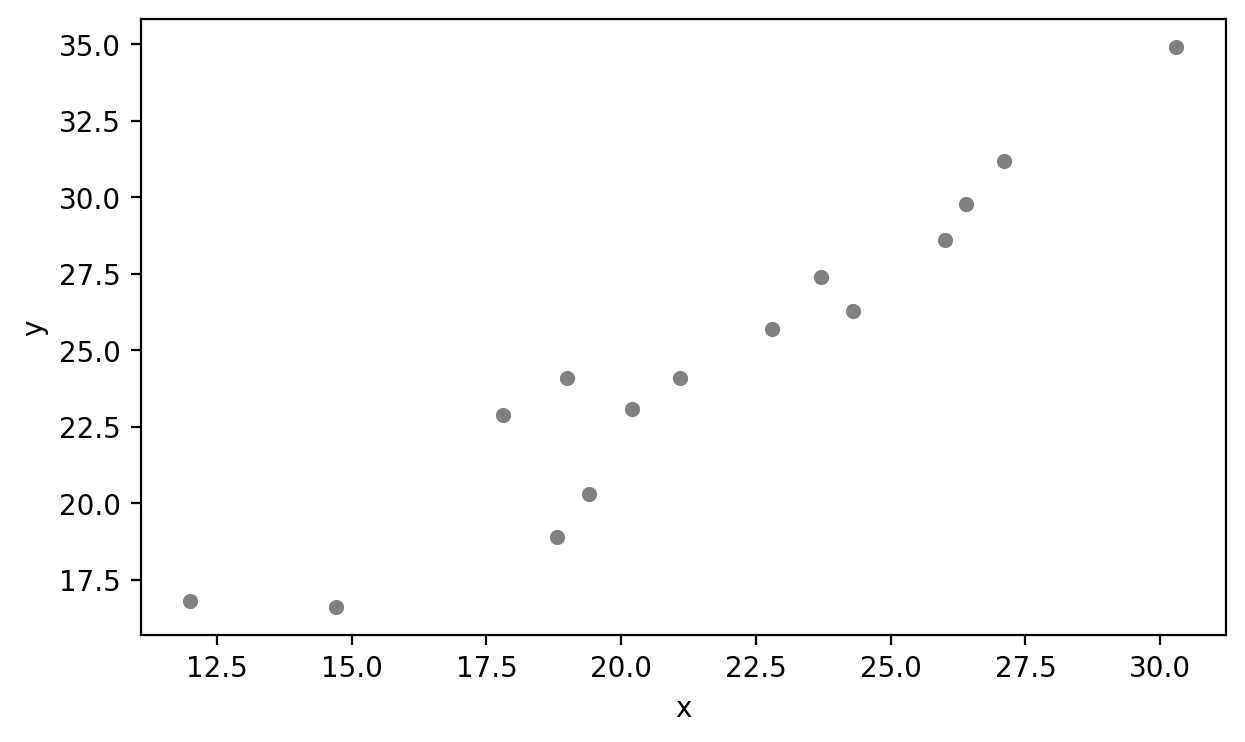

In [3]:
x = np.array([22.8,12.0,19.4,27.1,19.0,21.1,26.4,17.8,23.7,20.2,30.3,18.8,14.7,26.0,24.3])
y = np.array([25.7,16.8,20.3,31.2,24.1,24.1,29.8,22.9,27.4,23.1,34.9,18.9,16.6,28.6,26.3])
plt.figure(figsize=[7,4],dpi=200)
plt.scatter(x,y,s=20,facecolor='gray')
plt.xlabel('x')
plt.ylabel('y')


In [4]:
from scipy.stats import linregress
lr = linregress(x,y)

In [5]:
lr

LinregressResult(slope=np.float64(1.02545287098266), intercept=np.float64(2.590896730000747), rvalue=np.float64(0.9587532973687167), pvalue=np.float64(1.779519609895298e-08), stderr=np.float64(0.08431826210956965), intercept_stderr=np.float64(1.8624553457473432))

Text(0, 0.5, 'y')

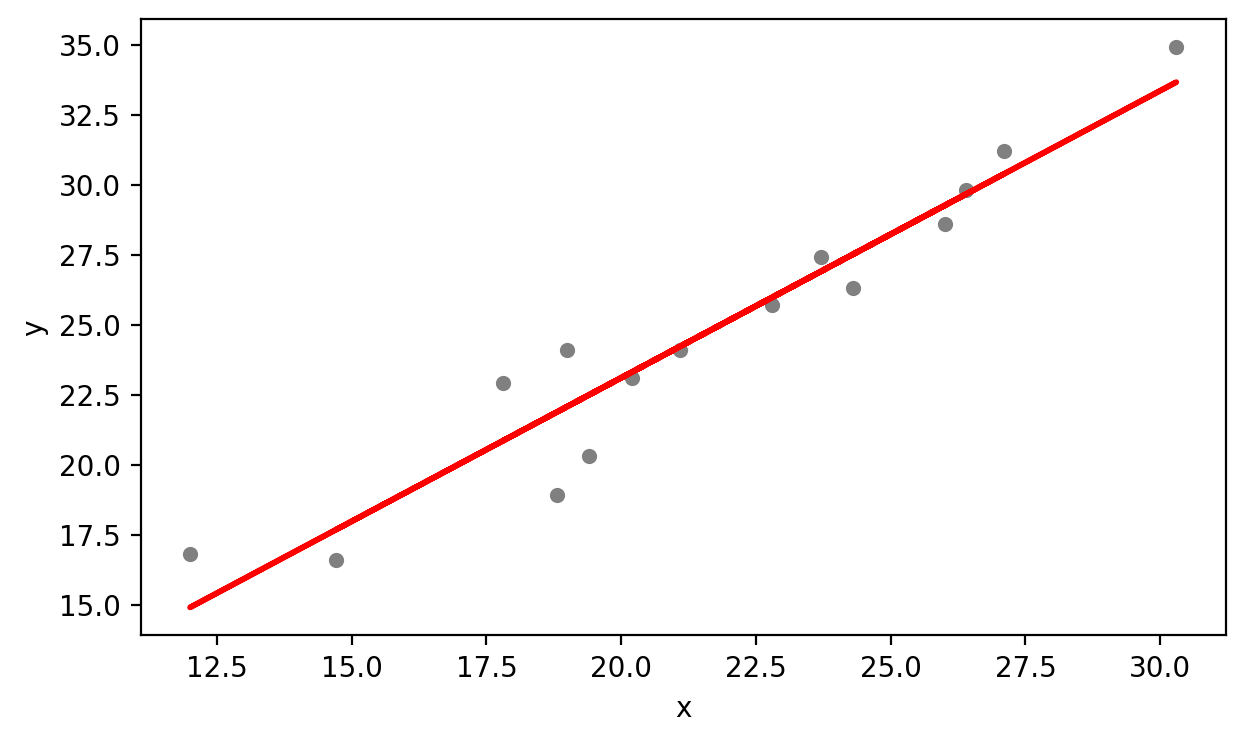

In [6]:
lr = linregress(x,y)
predict_y = lr.intercept + lr.slope*x
plt.figure(figsize=[7,4],dpi=200)
plt.plot(x,predict_y,lw=2,c='red')
plt.scatter(x,y,s=20,facecolor='gray')
plt.xlabel('x')
plt.ylabel('y')



Text(0, 0.5, 'y')

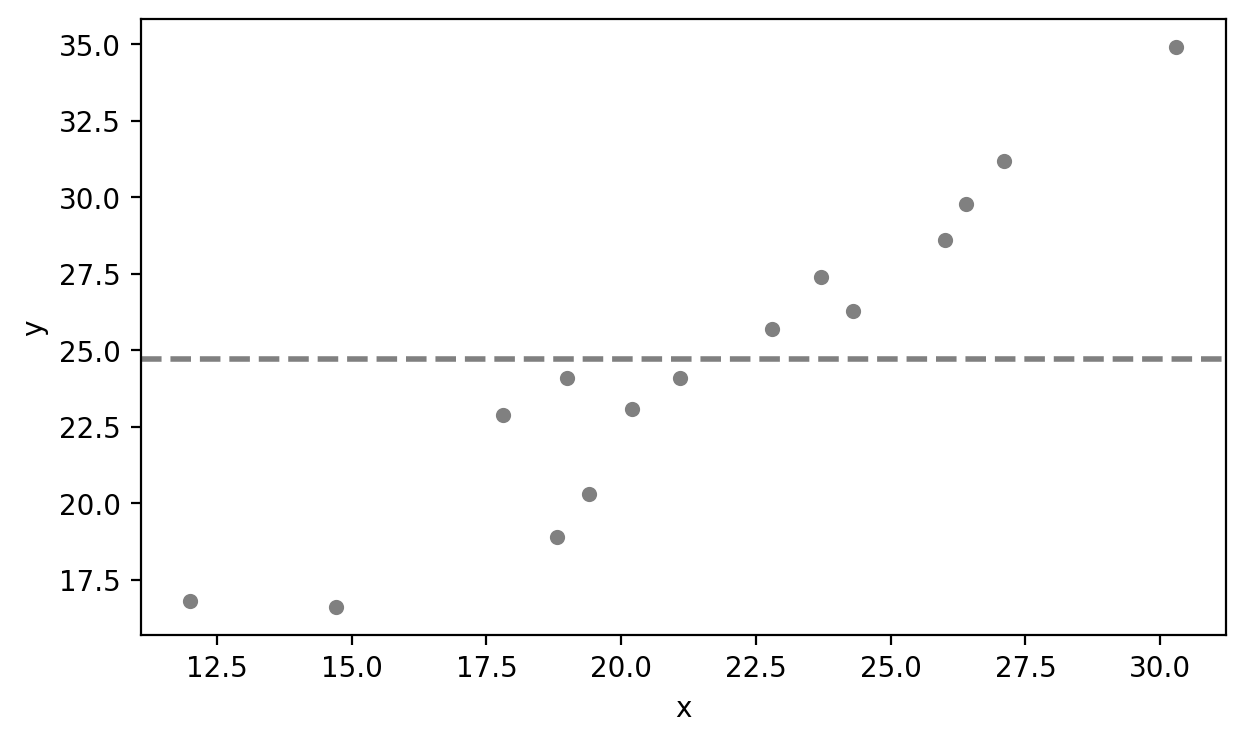

In [7]:
y_mean = np.mean(y)
plt.figure(figsize=[7,4],dpi=200)
plt.axhline(y_mean,ls='--',c='gray',lw=2)
plt.scatter(x,y,s=20,facecolor='gray')
plt.xlabel('x')
plt.ylabel('y')

Text(0, 0.5, 'y')

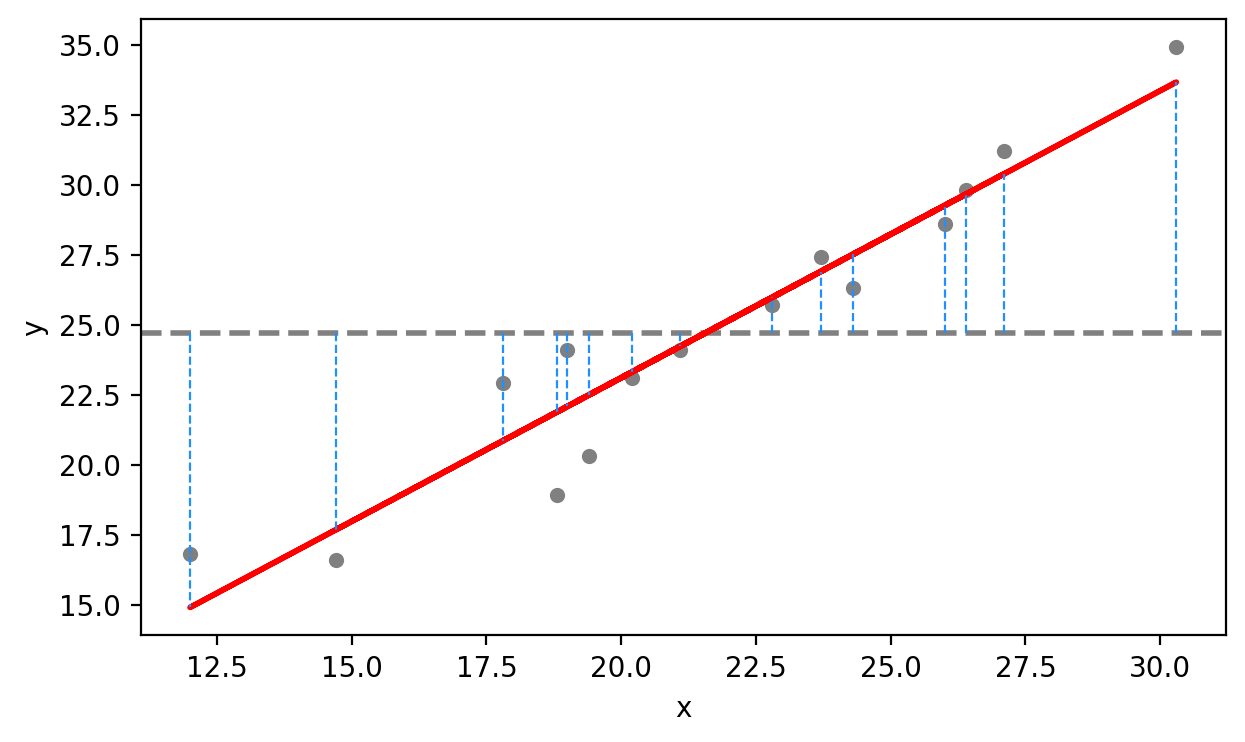

In [8]:
plt.figure(figsize=[7,4],dpi=200)
plt.axhline(y_mean,ls='--',c='gray',lw=2)
plt.plot(x,predict_y,lw=2,c='red')
for rank,x_i in enumerate(x):
    # plt.plot([x_i,x_i],[y_mean,y[rank]],c='dodgerblue',ls='--',lw=0.8)
    # plt.plot([x_i,x_i],[y[rank],predict_y[rank]],c='dodgerblue',ls='--',lw=0.8)
    plt.plot([x_i,x_i],[y_mean,predict_y[rank]],c='dodgerblue',ls='--',lw=0.8)

plt.scatter(x,y,s=20,facecolor='gray')
plt.xlabel('x')
plt.ylabel('y')

In [9]:
pow(predict_y - y_mean,2).sum() + pow(predict_y - y,2).sum()

np.float64(385.89733333333345)

In [10]:
pow(y - y_mean,2).sum()

np.float64(385.8973333333333)

# Multi-linear regression

In [11]:
from sklearn.linear_model import LinearRegression

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf


# ----------------------------
# 1. Generate example data
# ----------------------------
np.random.seed(42)
n = 300

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)

# True model
Y = 3 + 2*X1 + 0.5*X2 + 1.5*X3 + np.random.normal(0, 1, n)

df = pd.DataFrame({"Y": Y, "X1": X1, "X2": X2, "X3": X3})

# ----------------------------
# 2. Fit full model
# ----------------------------
# X_full = sm.add_constant(df[["X1", "X2", "X3"]])
# model_full = sm.OLS(df["Y"], X_full).fit()
model_full = smf.ols("Y ~ X1 + X2 + X3", data=df).fit()


R2_full = model_full.rsquared
print("Full Model R²:", R2_full)


Full Model R²: 0.8595862968425467

Variance Explained by Each Predictor:

  Predictor  Semi-partial R² (ΔR²)  Partial R²
0        X1               0.572396    0.803014
1        X2               0.026058    0.156531
2        X3               0.305732    0.685274


In [27]:
model_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     604.0
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          8.37e-126
Time:                        23:21:11   Log-Likelihood:                -427.08
No. Observations:                 300   AIC:                             862.2
Df Residuals:                     296   BIC:                             877.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.0984      0.059     52.868      0.000       2.983       3.214
X1             2.0678      0.060     34.737      0.000       1.951       2.185
X2             0.4514      0.061      7.412      0.000       0.332       0.571
X3             1.4918      0.059     25.387      0.000       1.376       1.607
==============================================================================
Omnibus:                        2.085   Durbin-Watson:                   2.115
Prob(Omnibus):                  0.353   Jarque-Bera (JB):                2.051
Skew:                          -0.201   Prob(JB):                        0.359
Kurtosis:                       2.955   Cond. No.                         1.12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
from statsmodels.stats.anova import anova_lm

# --- Type I (sequential) ANOVA: matches R's aov/anova default ---
anova_type1 = anova_lm(model_full, typ=1)
print("Type I ANOVA")
print(anova_type1)

# --- If you want Type II or Type III (unique/partial-style tests) ---
anova_type2 = anova_lm(model_full, typ=2)
print("\nType II ANOVA")
print(anova_type2)

anova_type3 = anova_lm(model_full, typ=3)
print("\nType III ANOVA")
print(anova_type3)

Type I ANOVA
             df       sum_sq      mean_sq            F         PR(>F)
X1          1.0  1150.138091  1150.138091  1124.256459  8.263919e-103
X2          1.0    44.296506    44.296506    43.299699   2.129831e-10
X3          1.0   659.337312   659.337312   644.500202   2.763030e-76
Residual  296.0   302.814249     1.023021          NaN            NaN

Type II ANOVA
               sum_sq     df            F         PR(>F)
X1        1234.420959    1.0  1206.642705  1.948654e-106
X2          56.196428    1.0    54.931836   1.316139e-12
X3         659.337312    1.0   644.500202   2.763030e-76
Residual   302.814249  296.0          NaN            NaN

Type III ANOVA
                sum_sq     df            F         PR(>F)
Intercept  2859.322517    1.0  2794.978998  8.027664e-153
X1         1234.420959    1.0  1206.642705  1.948654e-106
X2           56.196428    1.0    54.931836   1.316139e-12
X3          659.337312    1.0   644.500202   2.763030e-76
Residual    302.814249  296.0  

## What if X2 and X3 are strongly correlated??

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf


# ----------------------------
# 1. Generate example data
# ----------------------------
np.random.seed(42)
n = 300

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = X2 * 0.5

# True model
Y = 3 + 2*X1 + 0.5*X2 + 1.5*X3 + np.random.normal(0, 1, n)

df = pd.DataFrame({"Y": Y, "X1": X1, "X2": X2, "X3": X3})

# ----------------------------
# 2. Fit full model
# ----------------------------
# X_full = sm.add_constant(df[["X1", "X2", "X3"]])
# model_full = sm.OLS(df["Y"], X_full).fit()
model_full = smf.ols("Y ~ X1 + X2 + X3", data=df).fit()


R2_full = model_full.rsquared
print("Full Model R²:", R2_full)


Full Model R²: 0.8319900382703957


In [2]:
from statsmodels.stats.anova import anova_lm

# --- Type I (sequential) ANOVA: matches R's aov/anova default ---
anova_type1 = anova_lm(model_full, typ=1)
print("Type I ANOVA")
print(anova_type1)

# --- If you want Type II or Type III (unique/partial-style tests) ---
anova_type2 = anova_lm(model_full, typ=2)
print("\nType II ANOVA")
print(anova_type2)

anova_type3 = anova_lm(model_full, typ=3)
print("\nType III ANOVA")
print(anova_type3)

Type I ANOVA
             df       sum_sq      mean_sq            F         PR(>F)
X1          1.0  1059.038603  1059.038603  1061.647496  4.532399e-100
X2          1.0   408.099492   408.099492   409.104826   8.509909e-58
X3          1.0     0.520219     0.520219     0.521501   4.707704e-01
Residual  297.0   296.270152     0.997543          NaN            NaN

Type II ANOVA
               sum_sq     df            F         PR(>F)
X1        1111.183750    1.0  1113.921100  1.656958e-102
X2         408.099492    1.0   409.104826   8.509909e-58
X3         408.099492    1.0   409.104826   8.509909e-58
Residual   296.270152  297.0          NaN            NaN

Type III ANOVA
                sum_sq     df            F         PR(>F)
Intercept  2846.665881    1.0  2853.678511  2.387097e-154
X1         1111.183750    1.0  1113.921100  1.656958e-102
X2          408.099492    1.0   409.104826   8.509909e-58
X3          408.099492    1.0   409.104826   8.509909e-58
Residual    296.270152  297.0  